# 15 · The Shifted Zero: Where BDM Sees Structure, and Where It Cannot

**The question.** Take eight 8-bit strings, $a_i = 1^{i}\,0\,1^{7-i}$ for $i = 0..7$: one zero
sliding across a line of ones. Written separately, a program for each one grows a little
longer as the zero moves inward. That small variation is what BDM/CTM reports too, and it is
the finer granularity that BDM is credited with over Shannon entropy, which is flat for these
strings. But an observer who sees *the shift* writes **one** program, with an index, that
generates every case. Seen through that program the family has nearly constant complexity,
and so does the whole concatenation.

**What we probe.** Does BDM register the regularity that relates the blocks to each other,
or only the content of each block? We ask it in seven ways:

| § | experiment | what it isolates |
|---|---|---|
| 1 | render the object | what the string actually is, before any measure |
| 2 | each case separately: program length, CTM, Shannon | per-block granularity |
| 3 | one program for all cases | the observer's compression |
| 4 | sum of the parts versus the whole, at every block size | BDM's partition |
| 5 | more zeros, from `11111111` to `00000000` | scaling and symmetry |
| 6 | the same blocks in random order | does order register? |
| 7 | rotation: last bit moved to the front | does a one-bit relabelling register? |

**A rule we follow throughout.** $K$ is uncomputable, so on the Kolmogorov side we only
ever show **explicit programs that run and reproduce the string**. Each is an *upper bound*
on $K$ in a fixed language (Python expressions), up to the invariance constant. CTM values
are in bits under the $D(5)$ Turing-machine reference. The two units are not comparable in
absolute size, so we compare **how each one changes** (slopes, invariances) and never
the raw values side by side.

**Shannon appears only as a foil**, because the claim under test is phrased against it.
Under this project's rules it is never a complexity measure.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
# The complexity measures live in ONE place: the repository's description-length owner.
_core = os.path.join(os.path.dirname(ROOT), "src")
if _core not in sys.path:
    sys.path.insert(0, _core)
import math, random, itertools, collections
from description_lengths import ctm_1d, bdm_1d

def shannon_bits_per_symbol(s):
    """FOIL ONLY. Empirical Shannon entropy of the 0/1 frequencies -- not a complexity measure."""
    n = len(s); c = collections.Counter(s)
    return abs(-sum(v / n * math.log2(v / n) for v in c.values()))

def block_entropy(s, b):
    """FOIL ONLY. Shannon entropy (bits) of the distribution of aligned b-blocks."""
    blocks = [s[i:i + b] for i in range(0, len(s) - b + 1, b)]
    n = len(blocks); c = collections.Counter(blocks)
    return -sum(v / n * math.log2(v / n) for v in c.values())

def program_length(src, target):
    """Length (characters) of a Python expression that EVALUATES to target.
    Refuses a program that does not reproduce the string: an upper bound must be a real program."""
    out = eval(src, {"itertools": itertools})
    assert out == target, f"program does not reproduce the target: {src!r}"
    return len(src)

def show_bits(ax, strings, title, mark=None):
    """Render strings as rows of black (1) / white (0) cells -- the object itself."""
    M = np.array([[int(c) for c in s] for s in strings])
    ax.imshow(1 - M, cmap="gray", vmin=0, vmax=1, aspect="equal")
    ax.set_xticks(range(M.shape[1])); ax.set_yticks(range(M.shape[0]))
    ax.set_yticklabels(mark or strings, family="monospace", fontsize=8)
    ax.set_xticklabels(range(M.shape[1]), fontsize=7)
    ax.grid(False); ax.set_title(title)

ONES = "1" * 8
SHIFT = ["1" * i + "0" + "1" * (7 - i) for i in range(8)]   # zero at position i = 0..7
A = "".join(SHIFT)                                            # your string, 64 bits
A9 = ONES + A                                                 # with the all-ones anchor, 72 bits
print("A  =", A, len(A), "bits")
print("A9 =", A9, len(A9), "bits")

A  = 0111111110111111110111111110111111110111111110111111110111111110 64 bits
A9 = 111111110111111110111111110111111110111111110111111110111111110111111110 72 bits


## 1 · The object, before any measure

Below are the eight cases, then your concatenation $A = a_0 + a_1 + \dots + a_7$ wrapped
into rows of **8** bits and rows of **9** bits. Look at the right-hand panel before reading
any number.

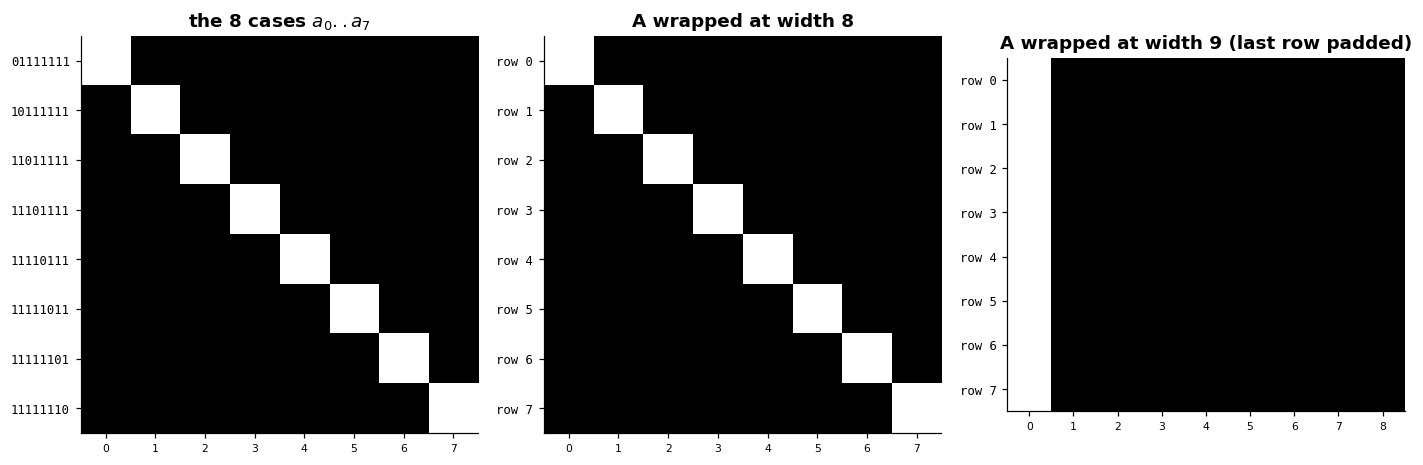

zero positions in A: [0, 9, 18, 27, 36, 45, 54, 63]
gaps between zeros : [9, 9, 9, 9, 9, 9, 9]


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
show_bits(ax[0], SHIFT, "the 8 cases $a_0..a_7$")
wrap = lambda s, w: [s[i:i + w].ljust(w, "1") for i in range(0, len(s), w)]
show_bits(ax[1], wrap(A, 8), "A wrapped at width 8", mark=[f"row {r}" for r in range(8)])
w9 = wrap(A, 9)
show_bits(ax[2], w9, "A wrapped at width 9 (last row padded)", mark=[f"row {r}" for r in range(len(w9))])
plt.tight_layout(); plt.show()
print("zero positions in A:", [i for i, c in enumerate(A) if c == "0"])
print("gaps between zeros :", np.diff([i for i, c in enumerate(A) if c == "0"]).tolist())

**What the render shows.** At width 8 the zeros form a diagonal: the shift you designed.
At width 9 the diagonal collapses into **one vertical column**. The zeros sit at positions
$0, 9, 18, \dots, 63$, every gap is 9, and so

$$A = (0\,1^8)^7\,0 , \qquad A_9 = 1^8 + A = (1^8\,0)^8 .$$

Your "shift the zero one step per block" over blocks of 8 is, as a whole, a **period-9
string**. This matters for everything that follows. The right analysis length for $A$ is
9, not 8. At 8 the shift is visible as a diagonal; at 9 it disappears into plain
repetition. A partition of length 8 is the one choice that turns this repetition into eight
*different* blocks.

## 2 · Each case separately: program length, CTM, Shannon

First your nine one-off programs (`seq_11111111` …). We transcribe only the returned
expression, without `def` and docstring, so the counts are smaller than in your sketch
but have the same shape. Each one is checked by running it. Then CTM of each 8-bit string from the $D(5)$ table,
and the Shannon foil.

In [4]:
# Your per-case programs (transcribed from the sketch; each is checked by running it).
USER_PROGS = {
    "11111111": 'f"{(1 << 8) - 1:08b}"',
    "01111111": 'f"{((1 << 8) - 1) >> 1:08b}"',
    "10111111": 'f"{(1 << 7) | (((1 << 8) - 1) >> 2):08b}"',
    "11011111": 'f"{(3 << 6) | (((1 << 8) - 1) >> 3):08b}"',
    "11101111": 'f"{(7 << 5) | (((1 << 8) - 1) >> 4):08b}"',
    "11110111": 'f"{(15 << 4) | (((1 << 8) - 1) >> 5):08b}"',
    "11111011": 'f"{(31 << 3) | (((1 << 8) - 1) >> 6):08b}"',
    "11111101": 'f"{(63 << 2) | (((1 << 8) - 1) >> 7):08b}"',
    "11111110": 'f"{((1 << 8) - 1) << 1 & 0xFF:08b}"',
}
cases = [ONES] + SHIFT
plen = [program_length(USER_PROGS[s], s) for s in cases]
ctm  = [ctm_1d(s) for s in cases]
H    = [shannon_bits_per_symbol(s) for s in cases]
print(f"{'string':>10} {'prog chars':>10} {'CTM bits':>9} {'Shannon b/sym':>13}")
for s, p, c, h in zip(cases, plen, ctm, H):
    print(f"{s:>10} {p:>10} {c:>9.3f} {h:>13.3f}")

    string prog chars  CTM bits Shannon b/sym
  11111111         21    18.527         0.000
  01111111         28    19.625         0.544
  10111111         41    19.923         0.544
  11011111         41    20.431         0.544
  11101111         41    19.914         0.544
  11110111         42    19.914         0.544
  11111011         42    20.431         0.544
  11111101         42    19.923         0.544
  11111110         35    19.625         0.544


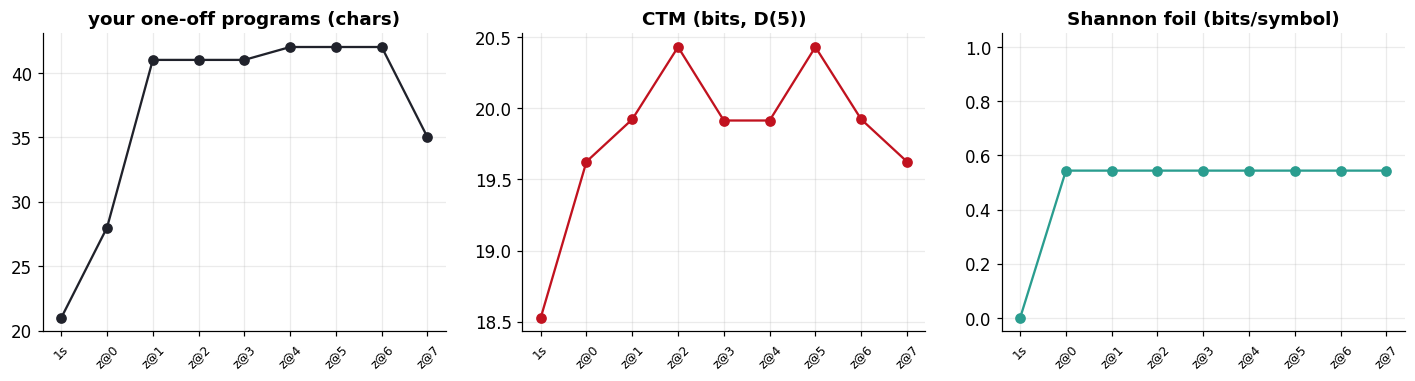

CTM spread over the 8 shifted cases: 0.805 bits (min 19.625, max 20.431)
CTM mirror-symmetric (a_i vs a_{7-i}): True


In [5]:
x = np.arange(len(cases)); lab = ["1s"] + [f"z@{i}" for i in range(8)]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].plot(x, plen, "o-", color=INK); ax[0].set_title("your one-off programs (chars)")
ax[1].plot(x, ctm, "o-", color=HL);   ax[1].set_title("CTM (bits, D(5))")
ax[2].plot(x, H, "o-", color=OK);     ax[2].set_title("Shannon foil (bits/symbol)")
ax[2].set_ylim(-0.05, 1.05)
for a in ax: a.set_xticks(x); a.set_xticklabels(lab, rotation=45, fontsize=8)
plt.tight_layout(); plt.show()
print(f"CTM spread over the 8 shifted cases: {max(ctm[1:]) - min(ctm[1:]):.3f} bits "
      f"(min {min(ctm[1:]):.3f}, max {max(ctm[1:]):.3f})")
print("CTM mirror-symmetric (a_i vs a_{7-i}):",
      all(abs(ctm_1d(SHIFT[i]) - ctm_1d(SHIFT[7 - i])) < 1e-12 for i in range(8)))

**Reading.** Your hand-drawn plot comes back, in CTM units: the all-ones string is the
cheapest, the zero at either end costs a little more, and the zero in the interior costs the
most, with a plateau there. Shannon is flat across all eight shifted cases, since each has
one zero and seven ones. So per block, CTM does show a granularity that Shannon lacks.

Two cautions keep the argument honest.

1. **The mirror symmetry is a property of the table, not a finding.** The $D(5)$ machine
   space is closed under reversal and complement, so $\mathrm{CTM}(a_i) =
   \mathrm{CTM}(a_{7-i})$ holds by construction. It is pinned as a test in the owner.
2. **The spread is about one bit.** Kolmogorov complexity is defined only up to an additive
   constant. A one-bit difference between 8-bit strings is inside that slack, so it is not
   evidence *against* CTM. Per-block granularity is **not** where your argument bites.
   It bites in §3–§6, where the blocks are *composed*.

## 3 · One program for every case

Your indexed generator (`shift_zero_concat`) makes any case, or any sequence of cases, from
an index. It is longer than any single one-off program, but it is written **once**. After
that, each case costs only its index, $\lceil\log_2 8\rceil = 3$ bits. Below we measure
four programs for $A$, each one checked by running it:

In [6]:
PROGS_A = {
    "literal (print the string)":  repr(A),
    "your eight one-offs, joined":  " + ".join(USER_PROGS[s] for s in SHIFT),
    "indexed shift (your idea)":   "''.join('1'*i+'0'+'1'*(7-i) for i in range(8))",
    "period 9 (the render's idea)": "('0'+'1'*8)*7+'0'",
}
for name, src in PROGS_A.items():
    print(f"{name:<30} {program_length(src, A):>4} chars   {src[:60]}{'...' if len(src) > 60 else ''}")

literal (print the string)       66 chars   '01111111101111111101111111101111111101111111101111111101111...
your eight one-offs, joined     333 chars   f"{((1 << 8) - 1) >> 1:08b}" + f"{(1 << 7) | (((1 << 8) - 1)...
indexed shift (your idea)        46 chars   ''.join('1'*i+'0'+'1'*(7-i) for i in range(8))
period 9 (the render's idea)     17 chars   ('0'+'1'*8)*7+'0'


The ranking of the four is what matters, not their sizes, because the unit is
characters of one language. The concatenation of separate programs is the longest; it
inherits every case's private cost. The indexed generator replaces eight programs with one.
The period-9 program is shorter still, because it does not *shift* anything: it repeats.
These two programs describe the same string in two ways, one as a set of shifts and one as
a repetition, and the second is the one the width-9 render found.

## 4 · The sum of the parts against the whole, at every block size

BDM cuts the string into blocks, looks each distinct block up in the CTM table, and adds
$\log_2(\text{multiplicity})$ for repeats:
$\mathrm{BDM}(s) = \sum_{\text{distinct } b} \big[\mathrm{CTM}(b) + \log_2 n_b\big]$.

* With blocks of 8 aligned to your cases, every block of $A$ is distinct, so
  $\mathrm{BDM}_8(A) = \sum_i \mathrm{CTM}(a_i)$ **exactly**. "Sum of the parts" and "the
  whole" coincide by definition, so comparing them at block 8 tells us nothing.
* The informative experiment is to **change the block length**. The CTM table covers
  lengths 1..12. Trailing bits that do not fill a block are dropped, which is pybdm's
  behaviour; the owner refuses it unless we ask, and here we ask explicitly.

sum of CTM(a_i), i=0..7      = 159.785 bits
BDM_8(A) (aligned, whole)    = 159.785 bits   <- identical, by definition
control R72 = 001110101000101010101111101101101110100011010010110110010111100111001001


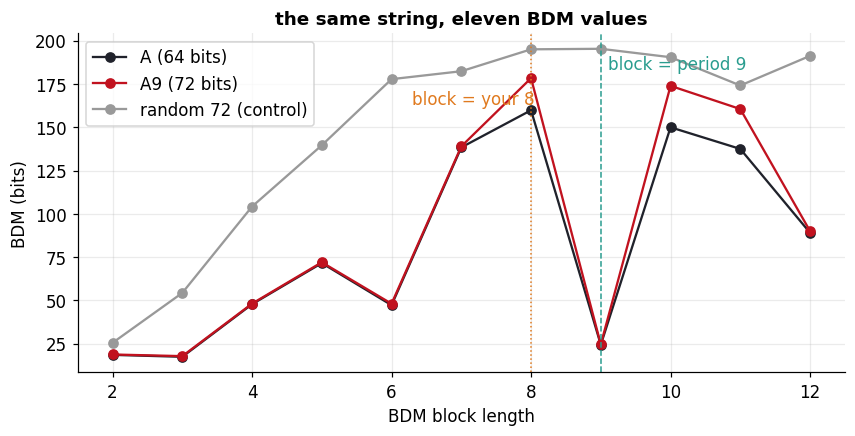

block A9 bits scored   BDM(A9) BDM(random) A9/random
    2             72     18.79       25.52      0.74
    3             72     17.84       54.34      0.33
    4             72     48.14      104.19      0.46
    5             70     72.03      139.57      0.52
    6             72     48.10      177.73      0.27
    7             70    138.92      182.31      0.76
    8             72    178.31      194.96      0.91
    9             72     24.62      195.26      0.13
   10             70    173.86      190.40      0.91
   11             66    160.48      174.07      0.92
   12             72     90.03      191.18      0.47


In [7]:
sum_parts = sum(ctm_1d(s) for s in SHIFT)
print(f"sum of CTM(a_i), i=0..7      = {sum_parts:.3f} bits")
print(f"BDM_8(A) (aligned, whole)    = {bdm_1d(A, block=8):.3f} bits   <- identical, by definition")
_r = random.Random(72)
R72 = "".join(_r.choice("01") for _ in range(72))   # control: a random 72-bit string, seed pinned
print("control R72 =", R72)
rows = []
for b in range(2, 13):
    for name, s in (("A (64 bits)", A), ("A9 (72 bits)", A9), ("random 72 (control)", R72)):
        rows.append((name, b, bdm_1d(s, block=b, remainder="drop"), len(s) - len(s) % b))
fig, ax = plt.subplots(figsize=(9, 4))
for name, col in (("A (64 bits)", INK), ("A9 (72 bits)", HL), ("random 72 (control)", "0.6")):
    bs = [r[1] for r in rows if r[0] == name]; vs = [r[2] for r in rows if r[0] == name]
    ax.plot(bs, vs, "o-", color=col, label=name)
ax.axvline(9, color=OK, ls="--", lw=1); ax.text(9.1, ax.get_ylim()[1] * 0.9, "block = period 9", color=OK)
ax.axvline(8, color=BAD, ls=":", lw=1); ax.text(6.3, ax.get_ylim()[1] * 0.8, "block = your 8", color=BAD)
ax.set_xlabel("BDM block length"); ax.set_ylabel("BDM (bits)"); ax.legend()
ax.set_title("the same string, eleven BDM values"); plt.show()
ctl = {b: v for name, b, v, _ in rows if name.startswith("random")}
print(f"{'block':>5} {'A9 bits scored':>14} {'BDM(A9)':>9} {'BDM(random)':>11} {'A9/random':>9}")
for name, b, v, used in rows:
    if name.startswith("A9"):
        print(f"{b:>5} {used:>14} {v:>9.2f} {ctl[b]:>11.2f} {v / ctl[b]:>9.2f}")

**Reading.** One string gets eleven values, and the spread is large: block 8 and block 9
differ by about a factor of seven on $A_9$. Read each value against the **random 72-bit
control** at the same block length (last column, $A_9$/random). At block 9 the ratio is 0.13,
because one block is repeated eight times. At block 12 it is 0.47:
$\mathrm{lcm}(9,12)=36$, so every block occurs twice. At block 8 it is **0.91**:
$\mathrm{lcm}(9,8)=72$, no block repeats, and a string that a 17-character program
generates is scored at 91% of a coin-flip string. Repetition is the one regularity BDM
rewards, with $\log_2 n$ instead of $n \times \mathrm{CTM}$. Where the cuts do not produce
repetition, it sees almost nothing.

So BDM *can* see this string's regularity, but only when the partition happens to match
it. Choosing the partition is the inference: it is what your IDEA note calls finding
"the length we should use to analyse this string". In BDM as used in practice the block
length is fixed in advance (12 is pybdm's default), not found from the data.

## 5 · More zeros: from `11111111` to `00000000`

Two ways to generalise "one zero, shifted":

* **sliding run**: a run of $k$ zeros sliding through 8 positions, $1^{i}0^{k}1^{8-k-i}$,
  giving $9-k$ cases;
* **every placement**: all 8-bit strings with exactly $k$ zeros, giving $\binom{8}{k}$
  cases, concatenated in lexicographic order.

For each family we take the concatenation, then measure $\mathrm{BDM}_8$ (aligned to the
cases), the literal length, and the length of **one** generator program that takes $k$ as
a parameter.

In [8]:
def fam_run(k):  return ["1" * i + "0" * k + "1" * (8 - k - i) for i in range(9 - k)] if k else [ONES]
def fam_comb(k): return ["".join("0" if j in c else "1" for j in range(8)) for c in itertools.combinations(range(8), k)]
GEN = {
    "run":  "''.join('1'*i+'0'*{k}+'1'*(8-{k}-i) for i in range(9-{k}))" ,
    "comb": "''.join(''.join('0'if j in c else'1'for j in range(8))for c in itertools.combinations(range(8),{k}))",
}
res = {}
for fam_name, fam in (("run", fam_run), ("comb", fam_comb)):
    for k in range(9):
        blocks = fam(k); s = "".join(blocks)
        gen = GEN[fam_name].format(k=k) if (fam_name == "comb" or k) else repr(ONES)
        res[fam_name, k] = dict(n=len(blocks), bits=len(s), bdm8=bdm_1d(s, block=8),
                                mean_ctm=np.mean([ctm_1d(b) for b in blocks]),
                                gen=program_length(gen, s), lit=program_length(repr(s), s))
print(f"{'fam':>4} {'k':>2} {'cases':>5} {'bits':>5} {'BDM_8':>8} {'mean CTM':>8} {'gen chars':>9} {'literal':>7}")
for (f, k), r in res.items():
    print(f"{f:>4} {k:>2} {r['n']:>5} {r['bits']:>5} {r['bdm8']:>8.1f} {r['mean_ctm']:>8.2f} {r['gen']:>9} {r['lit']:>7}")

 fam  k cases  bits    BDM_8 mean CTM gen chars literal
 run  0     1     8     18.5    18.53        10      10
 run  1     8    64    159.8    19.97        52      66
 run  2     7    56    146.9    20.98        52      58
 run  3     6    48    131.2    21.87        52      50
 run  4     5    40    110.5    22.09        52      42
 run  5     4    32     87.8    21.96        52      34
 run  6     3    24     62.8    20.94        52      26
 run  7     2    16     39.3    19.63        52      18
 run  8     1     8     18.5    18.53        52      10
comb  0     1     8     18.5    18.53        98      10
comb  1     8    64    159.8    19.97        98      66
comb  2    28   224    589.7    21.06        98     226
comb  3    56   448   1214.0    21.68        98     450
comb  4    70   560   1529.9    21.86        98     562
comb  5    56   448   1214.0    21.68        98     450
comb  6    28   224    589.7    21.06        98     226
comb  7     8    64    159.8    19.97        98 

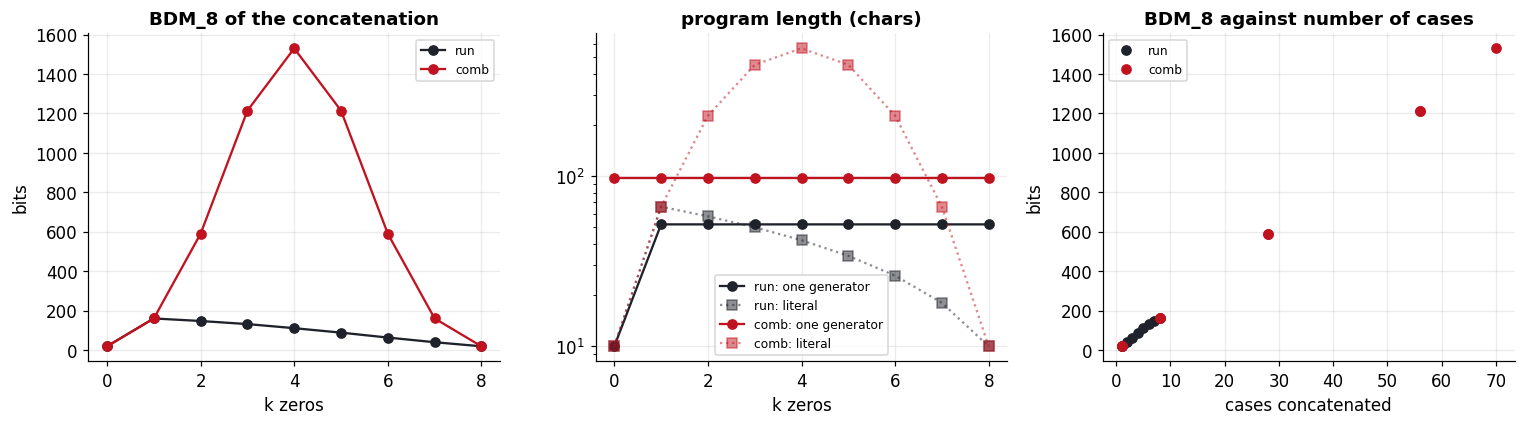

BDM_8 grows by 21.78 bits per added case (least squares over all 18 points, against a per-case CTM range of 18.53-22.09 bits)
comb family symmetric in k <-> 8-k: True


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for f, col in (("run", INK), ("comb", HL)):
    ks = range(9)
    ax[0].plot(ks, [res[f, k]["bdm8"] for k in ks], "o-", color=col, label=f)
    ax[1].plot(ks, [res[f, k]["gen"] for k in ks], "o-", color=col, label=f"{f}: one generator")
    ax[1].plot(ks, [res[f, k]["lit"] for k in ks], "s:", color=col, alpha=.5, label=f"{f}: literal")
    ax[2].plot([res[f, k]["n"] for k in ks], [res[f, k]["bdm8"] for k in ks], "o", color=col, label=f)
ax[0].set(title="BDM_8 of the concatenation", xlabel="k zeros", ylabel="bits")
ax[1].set(title="program length (chars)", xlabel="k zeros", yscale="log")
ax[2].set(title="BDM_8 against number of cases", xlabel="cases concatenated", ylabel="bits")
for a in ax: a.legend(fontsize=8)
plt.tight_layout(); plt.show()
n = np.array([res[f, k]["n"] for f in ("run", "comb") for k in range(9)])
v = np.array([res[f, k]["bdm8"] for f in ("run", "comb") for k in range(9)])
slope = np.polyfit(n, v, 1)[0]
print(f"BDM_8 grows by {slope:.2f} bits per added case (least squares over all 18 points, "
      f"against a per-case CTM range of {min(r['mean_ctm'] for r in res.values()):.2f}-"
      f"{max(r['mean_ctm'] for r in res.values()):.2f} bits)")
print("comb family symmetric in k <-> 8-k:",
      all(abs(res['comb', k]['bdm8'] - res['comb', 8 - k]['bdm8']) < 1e-9 for k in range(9)))

**Reading.**

* **BDM is linear in the number of cases.** Every new distinct block adds its CTM, about
  20 bits here. The generator does not grow with the number of cases; only the digit
  $k$ changes. The literal grows with the string. On these families BDM behaves like the
  literal, a list of cases, not like the generator. That is your "naive counting of
  patterns", now measured. This is a regime BDM's authors themselves describe: when blocks
  do not repeat and CTM is not informative across them, BDM tends towards block Shannon
  entropy plus a per-block constant (Zenil et al., *Entropy* 20:605, 2018). Our families
  are constructed so that this regime is reached with a generator of constant size.
* **Two honest qualifications.** For small families the literal is *shorter* than the
  generator: the sliding run with $k \ge 4$ has five cases or fewer, and listing them is
  cheaper than describing the rule. The generator wins only once the family is large. That
  is the expected crossover, not a defect of BDM. Also, BDM exceeds the raw length (1530
  bits for a 560-bit string at $k=4$). Do not read this as BDM failing: CTM charges about
  18.5 bits even for `11111111`, a machine-dependent offset per block. Compare slopes,
  not levels.
* **Symmetry, and where it holds.** The *every placement* family is exactly symmetric in
  $k \leftrightarrow 8-k$: complementing every string maps it onto itself, and the CTM table
  is complement-invariant. The *sliding run* family is **not** symmetric. It has $9-k$
  cases, so $k=1$ gives 8 cases and $k=7$ gives 2. Its complement partner is "a run of $k$
  *ones* sliding through zeros", which is a different family. The symmetric behaviour you
  expected is real, but it belongs to the combinatorial family, or to the *mean* CTM per
  case. It does not belong to the total of the sliding family.

## 6 · The same blocks in random order

Shuffle the eight cases and concatenate them. On the Kolmogorov side, a shuffled order
must be *specified*: the generator plus a permutation, up to $\log_2 8! \approx 15.3$
bits more, unless the order itself has a short description. The ordered string is the
simple one. What does BDM say? We draw 2000 shuffles (seed pinned) and score each at
blocks 8, 9 and 12.

block  8: ordered  178.31 | shuffles min  178.31 median  178.31 max  178.31 | share of shuffles <= ordered 1.0000
block  9: ordered   24.62 | shuffles min   47.14 median  137.33 max  179.55 | share of shuffles <= ordered 0.0000


block 12: ordered   90.03 | shuffles min   87.58 median  171.54 max  175.06 | share of shuffles <= ordered 0.0015


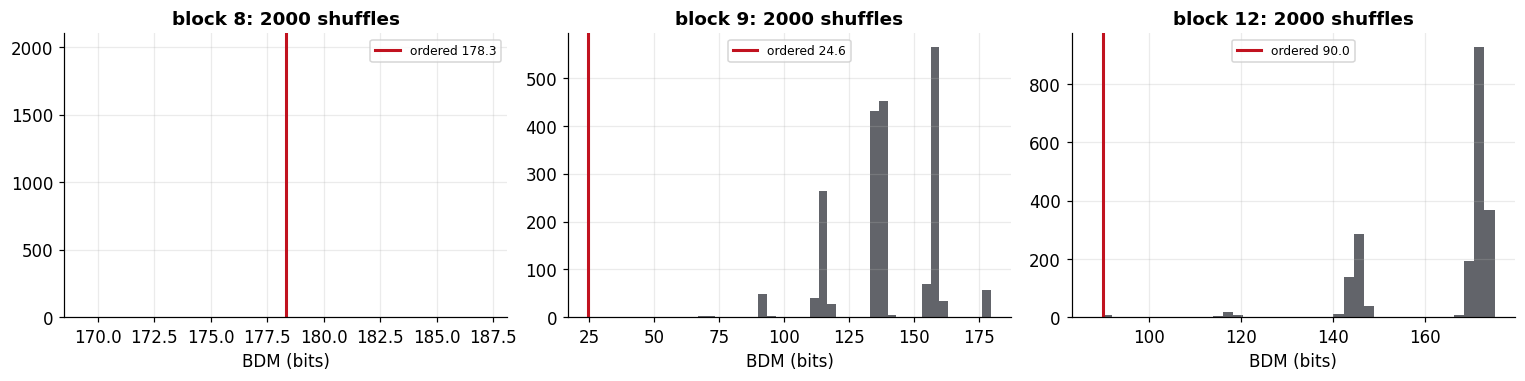

log2(9!) = 18.47 bits: the most a permutation of the 9 cases can add to K
block-entropy foil, block 8: ordered 3.170, every shuffle 3.170


In [10]:
rng = random.Random(15)
blocks9 = [ONES] + SHIFT                     # use A9 so that block 9 has its full period
ordered = "".join(blocks9)
shuffles = []
for _ in range(2000):
    p = blocks9[:]; rng.shuffle(p); shuffles.append("".join(p))
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, b in zip(ax, (8, 9, 12)):
    vals = np.array([bdm_1d(s, block=b, remainder="drop") for s in shuffles])
    o = bdm_1d(ordered, block=b, remainder="drop")
    a.hist(vals, bins=40 if np.ptp(vals) > 1e-6 else 1, color=INK, alpha=.7); a.axvline(o, color=HL, lw=2, label=f"ordered {o:.1f}")
    a.set(title=f"block {b}: 2000 shuffles", xlabel="BDM (bits)"); a.legend(fontsize=8)
    print(f"block {b:>2}: ordered {o:7.2f} | shuffles min {vals.min():7.2f} median {np.median(vals):7.2f} "
          f"max {vals.max():7.2f} | share of shuffles <= ordered {np.mean(vals <= o + 1e-9):.4f}")
plt.tight_layout(); plt.show()
print(f"log2(9!) = {math.log2(math.factorial(9)):.2f} bits: the most a permutation of the 9 cases can add to K")
print(f"block-entropy foil, block 8: ordered {block_entropy(ordered, 8):.3f}, "
      f"every shuffle {block_entropy(shuffles[0], 8):.3f}")

**Reading.**

* **Block 8 (aligned to the cases): order does not register at all.** All 2000 shuffles
  get *exactly* the ordered value. Aligned BDM is a function of the multiset of blocks,
  with no access to their order, and in this respect it is the same as the block-entropy
  foil. Yet the ordered string is a period-9 repetition, and a shuffle needs up to
  15–18 extra bits to specify.
* **Blocks 9 and 12: the ordered string is among the simplest.** At block 9 it is below
  all 2000 shuffles. At block 12 only 3 of 2000 shuffles score at or below it, because a
  few shuffles happen to create repeats of their own. Once the partition cuts *across* the
  cases, the ordered string's hidden repetition becomes repeated blocks. Shuffling breaks
  the repetition, and BDM rises. This is the correct direction, but it is bought by the
  choice of block length, as in §4.

So the order information is available to BDM only through **coincidences between the
partition and the generator**. Whether those coincidences occur is not something BDM decides
for itself.

## 7 · Rotation: move the last bit to the front

Rotation is a one-line program change, so $K$ moves by at most a constant (plus
$\log_2 |s|$ to name an arbitrary rotation amount). We do your exact experiment, a
rotation by one on $A$ (64 bits, your eight cases) and on $A_9$, and then sweep every
rotation amount. As a control, we do the same to one shuffled string.

A: rotated by 1 -> blocks of 8: ['00111111', '11011111', '11101111', '11110111', '11111011', '11111101', '11111110', '11111111']
     BDM_8 before 159.785   after 159.505
A9: rotated by 1 -> blocks of 8: ['01111111', '10111111', '11011111', '11101111', '11110111', '11111011', '11111101', '11111110', '11111111']
     BDM_8 before 178.312   after 178.312
BDM_8  A9 ordered   over 72 rotations: min  178.31 max  178.31 spread   0.00 bits
BDM_8  A            over 64 rotations: min  158.87 max  159.79 spread   0.92 bits
BDM_8  A9 shuffled  over 72 rotations: min  124.63 max  178.31 spread  53.69 bits
BDM_12 A9 ordered   over 72 rotations: min   90.03 max   90.33 spread   0.30 bits
BDM_12 A            over 64 rotations: min   89.03 max  148.68 spread  59.65 bits
BDM_12 A9 shuffled  over 72 rotations: min  169.21 max  172.05 spread   2.84 bits


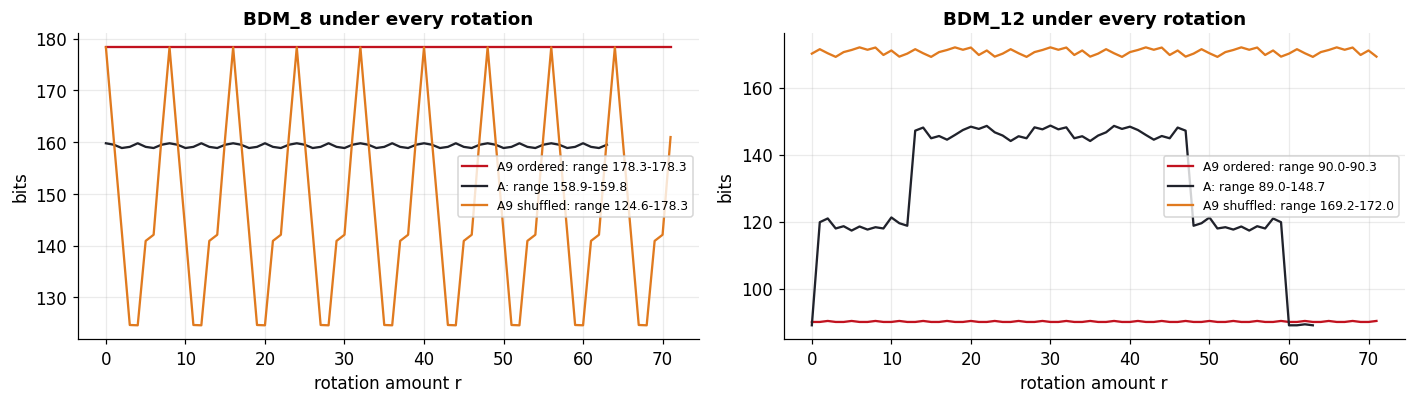

In [11]:
rot = lambda s, r: s[-r:] + s[:-r] if r else s
for name, s in (("A", A), ("A9", A9)):
    r1 = rot(s, 1)
    print(f"{name}: rotated by 1 -> blocks of 8: {[r1[i:i+8] for i in range(0, len(r1), 8)]}")
    print(f"     BDM_8 before {bdm_1d(s, block=8):.3f}   after {bdm_1d(r1, block=8):.3f}")
shuf = shuffles[0]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for a, b in zip(ax, (8, 12)):
    for name, s, col in (("A9 ordered", A9, HL), ("A", A, INK), ("A9 shuffled", shuf, BAD)):
        vals = [bdm_1d(rot(s, r), block=b, remainder="drop") for r in range(len(s))]
        a.plot(vals, color=col, label=f"{name}: range {min(vals):.1f}-{max(vals):.1f}")
        print(f"BDM_{b:<2} {name:<12} over {len(s)} rotations: min {min(vals):7.2f} max {max(vals):7.2f} "
              f"spread {max(vals) - min(vals):6.2f} bits")
    a.set(title=f"BDM_{b} under every rotation", xlabel="rotation amount r", ylabel="bits")
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading.**

* **$A_9$ (your cases plus `11111111`): every rotation leaves $\mathrm{BDM}_8$ unchanged.**
  This is not robustness. A rotation of a period-9 string is again a period-9 string, and
  its 8-blocks are again the nine phases of the period: the same multiset. A rotation by
  one moves `11111111` from the front to the back and nothing else happens.
* **$A$ (your eight cases, 64 bits): the rotation by one is *not* invisible, but it is
  small at block 8.** $A$ ends in the zero of `11111110`. Moving that zero to the front
  produces `00111111` and `11111111` in place of `01111111` and `10111111`, so the blocks
  change and $\mathrm{BDM}_8$ moves by 0.28 bits (0.92 bits across all 64 rotations). Under
  block 12 the same rotations move $\mathrm{BDM}(A)$ by about 60 bits. For $K$ they are all
  the same string plus a rotation index of $\le 6$ bits.
* **The shuffled control** spreads by about 54 bits at block 8. Without the period, every
  shift of the seams lands on new blocks.

Your question was whether the rotated string is still the same. For $K$ it is, up to a
constant. For BDM it depends on whether the rotation happens to preserve the multiset of
blocks under the fixed partition.

## What the experiment supports, and what it does not

**Supported, by the runs above:**

1. *Per case*, CTM resolves differences that Shannon misses (§2). The differences are
   about one bit, though, and therefore inside the invariance constant. This is not
   where BDM fails.
2. BDM's value for a fixed string depends strongly on the block length (§4): from 0.13 to
   0.91 of a random string's BDM on the same $A_9$. Its low values occur where the partition
   matches the generating period.
3. On families made by one parameterised program, $\mathrm{BDM}_8$ grows linearly with the
   number of cases at about the CTM of one case each (§5), while the generator does not
   grow at all. BDM counts patterns; it does not relate them.
4. With blocks aligned to the cases, BDM cannot see order (§6) and is in that respect
   exactly a block-entropy statistic with CTM weights. When it does respond to order or to
   rotation (§6–§7), the response comes from where the block cuts fall, and it can go
   either way.

**Not supported. Do not claim these:**

* "BDM is no better than Shannon." Per block it is better (§2), and with a matching
  partition it finds the repetition (§4, §6).
* "BDM is wrong about $K$." $K$ is uncomputable, and every Kolmogorov number here is an
  *upper bound*: a program that runs. The defensible statement is narrower: on these
  families BDM is far from the best upper bound we can exhibit, and the gap grows with the
  number of cases.
* Absolute comparisons of CTM bits against program characters. The units differ, and
  only slopes and invariances were compared.

**The thread to your IDEA note.** The block length that makes BDM succeed (9) is the
period of the generator, and the generator is what the index-set deconvolution recovers:
the zeros of $A$ are the offset family $\Omega = \{0, 9, 18, \dots\}$ on base $L$, the same
object the render in §1 shows as a column. A natural next experiment is to let the data
choose the partition, and compare the minimum of $\mathrm{BDM}_b$ over $b$ and over phase
with the length of the recovered $(L, \Omega)$ description, on families where the
period is *not* designed in advance.